In [1]:
import sys
sys.path.append('..')
import shap
import numpy as np
import matplotlib.pyplot as plt
import joblib
from src.data_pipeline import run_pipeline
from src.features import FEATURE_NAMES



In [2]:
model = joblib.load('../models/credit_model.pkl')
scaler = joblib.load('../models/scaler.pkl')
X_train_raw, X_test_raw, X_train_scaled, X_test_scaled, y_train, y_test = run_pipeline()

1/6 Loading unified dataset from SQLite...
    Loaded 1,528,692 rows
2/6 Missingness analysis...

=== Missingness Report ===
       feature  missing_pct classification                         strategy
monthly_income         2.29           MNAR Indicator + NaN (XGBoost Native)
3/6 Cleaning and adding missingness indicators...
4/6 Engineering features...


C:\Users\davia\OneDrive\Desktop\projects\credit-risk-scoring-system\.venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\davia\OneDrive\Desktop\projects\credit-risk-scoring-system\.venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\davia\OneDrive\Desktop\projects\credit-risk-scoring-system\.venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\davia\OneDrive\Desktop\projects\credit-risk-scoring-system\.venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


5/6 Building feature matrix...
6/6 Splitting and scaling...
    Train: (1222861, 32)  Test: (305716, 32)
    Default rate: train=0.200  test=0.200


## Creating the explainer
TreeExplainer is designed for tree based models such as xgboost
It uses the tree structure to compute exact SHAP values in polynomial time instead of exponential

Kernel explorer works on any model but its much slower so i didnt use it

In [3]:
explainer = joblib.load('../models/shap_explainer.pkl')

##Compute Shap values on a 1000 row sample
idx = np.random.default_rng(42).choice(len(X_test_scaled), size=1000, replace=False)
X_sample = X_test_scaled[idx]
X_sample_raw = X_test_raw.iloc[idx]
shap_values = explainer.shap_values(X_sample)

print(f'shap_values shape: {shap_values.shape}')
##This should be (1000: 10): one shap value per row per featuer

print(f'baseline prediction: {explainer.expected_value:.4f}')
##This will be the avg predicted default across all training data

shap_values shape: (1000, 32)
baseline prediction: 0.3522


### This is a Summary plot

I read it like this: each row is a feature, each dot is one of the 1000 customers, Right means the feature increased on the default probability, Left means it has decreased, red means the customer has a High value for that feature, blue means a Low value

example - red dots at the far right for 'total_late_payments' =
customer with many late payments have a lot higher predicted default risk

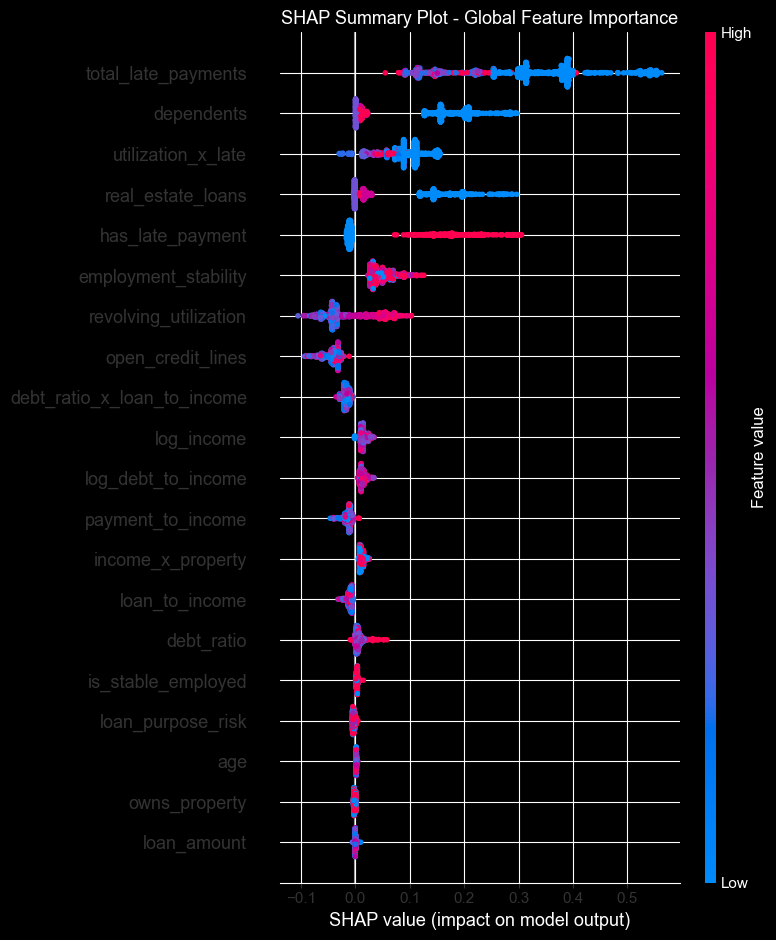

In [4]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, feature_names = FEATURE_NAMES, show = False)
plt.title('SHAP Summary Plot - Global Feature Importance', fontsize = 13)
plt.tight_layout()
plt.savefig('../docs/shap_summary.png', dpi = 150, bbox_inches = 'tight')
plt.show()

In [6]:
import pandas as pd
shap_df = pd.DataFrame(shap_values, columns=FEATURE_NAMES)
mean_abs = shap_df.abs().mean().sort_values(ascending=False)
print(mean_abs.to_string())

total_late_payments              0.307975
dependents                       0.114032
utilization_x_late               0.089084
real_estate_loans                0.069824
has_late_payment                 0.064441
employment_stability             0.049836
revolving_utilization            0.044772
open_credit_lines                0.042674
debt_ratio_x_loan_to_income      0.017256
log_income                       0.015623
log_debt_to_income               0.013980
payment_to_income                0.013470
income_x_property                0.012086
loan_to_income                   0.010596
debt_ratio                       0.005569
is_stable_employed               0.003060
loan_purpose_risk                0.002550
age                              0.001896
owns_property                    0.001728
loan_amount                      0.000828
months_employed_missing          0.000786
asset_score                      0.000582
log_loan_amount                  0.000550
age_x_log_loan                   0

Customer default probability: 1.0000


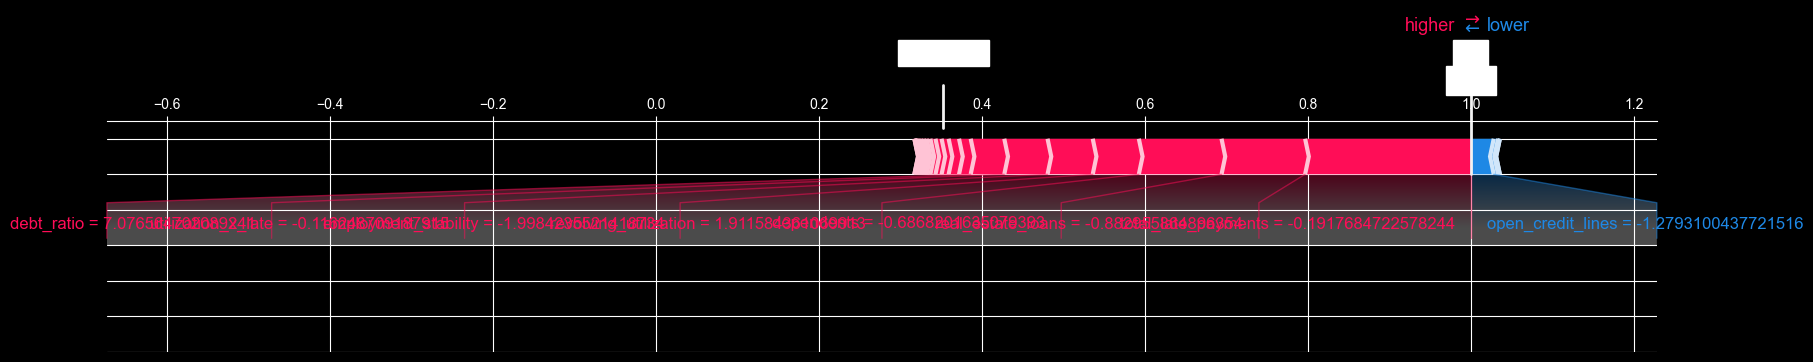

In [7]:
## Individual force plot for a 'high-risk customer'

## This is so i can find the customer with the highest predicted probability to default on the loan

proba = model.predict_proba(X_test_scaled)[:, 1]
high_risk_pos = np.argmax(proba)
single_shap = explainer.shap_values
print(f'Customer default probability: {proba[high_risk_pos]:.4f}')

# Get shap value for the customer

single_shap = explainer.shap_values(X_test_scaled[high_risk_pos:high_risk_pos+1])[0]

# Force plot

shap.force_plot(
    explainer.expected_value,
    single_shap,
    X_test_scaled[high_risk_pos],
    feature_names=FEATURE_NAMES,
    matplotlib=True,
    show=False
)
plt.savefig('../docs/shap_force_plot_high_risk.png', dpi=150, bbox_inches='tight')
plt.show()

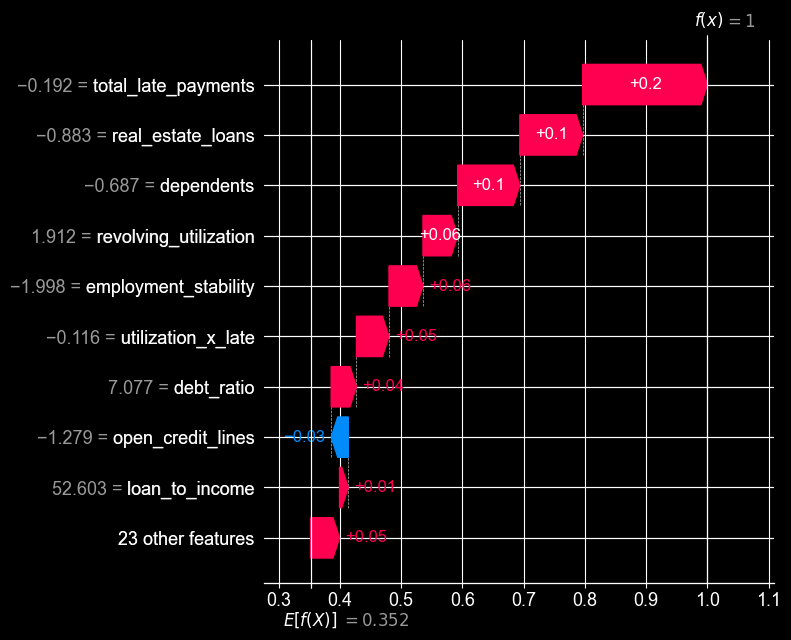

In [8]:
## Waterfall plot - Like force plot but cleaner

shap_exp = shap.Explanation(
    values = single_shap,
    base_values = explainer.expected_value,
    data = X_test_scaled[high_risk_pos],
    feature_names = FEATURE_NAMES,
)

plt.figure(figsize= (10 , 6))
shap.plots.waterfall(shap_exp, show = False)
plt.tight_layout()
plt.savefig('../docs/shap_waterfall.png', dpi = 150, bbox_inches = 'tight')
plt.show()

In [9]:
## Save the explainer for use via API and other stuff idk

joblib.dump(explainer, '../models/shap_explainer.pkl')
print('Explainer saved to ../models/shap_explainer.pkl')

Explainer saved to ../models/shap_explainer.pkl


In [10]:
# SHAP Interaction Values
# this shit is computationally expensive i'll run on 500 rows maximum.

explainer_raw = joblib.load('../models/shap_explainer_raw.pkl')

rng = np.random.default_rng(42)
idx_500 = rng.choice(len(X_test_raw), size=500, replace=False)
X_sample_raw = X_test_raw.iloc[idx_500]
# this creates a raw DataFrame with null values — XGBoost handles this natively

shap_interaction = explainer_raw.shap_interaction_values(X_sample_raw)
print(f"Interaction shape: {shap_interaction.shape}")
# This should be (500, n_features, n_features)

# Sum absolute interaction values
import pandas as pd
mean_abs = np.abs(shap_interaction).mean(axis=0)
np.fill_diagonal(mean_abs, 0)

# Top 10
pairs = []
n_feat = len(FEATURE_NAMES)
for i in range(n_feat):
    for j in range(i + 1, n_feat):
        pairs.append({
            "feature_1": FEATURE_NAMES[i],
            "feature_2": FEATURE_NAMES[j ],
            "strength": mean_abs[i, j]
        })

top_10 = pd.DataFrame(pairs).sort_values("strength", ascending=False).head(10)
print("Top 10 feature interaction pairs:")
print(top_10.to_string(index=False))

Interaction shape: (500, 32, 32)
Top 10 feature interaction pairs:
            feature_1            feature_2  strength
  total_late_payments     has_late_payment  0.137174
  total_late_payments   utilization_x_late  0.058915
revolving_utilization   utilization_x_late  0.022848
     has_late_payment   utilization_x_late  0.022775
revolving_utilization  total_late_payments  0.018266
revolving_utilization           debt_ratio  0.017752
revolving_utilization     has_late_payment  0.017378
 employment_stability    income_x_property  0.016275
  total_late_payments   is_stable_employed  0.016083
revolving_utilization employment_stability  0.015482


In [12]:
import sqlite3, json
from datetime import datetime

conn = sqlite3.connect('../data/creditdb.sqlite')
top_10['run_date'] = datetime.now().isoformat()
top_10.to_sql('shap_interaction_top10', conn, if_exists='replace', index=False)
conn.close()
print("Saved top 10 interactions to creditdb.sqlite → shap_interaction_top10")

Saved top 10 interactions to creditdb.sqlite → shap_interaction_top10


In [14]:
# Candidate interactions, with the new features added
candidate_interactions = {
    "age_x_log_loan":               ("age", "log_loan_amount"),
    "income_x_property":            ("employment_stability", "income_x_property"),
    "utilization_x_late":           ("revolving_utilization", "total_late_payments"),
    "debt_ratio_x_loan_to_income":  ("total_late_payments", "is_stable_employed"),
}

top_pairs = set(zip(top_10["feature_1"], top_10["feature_2"])) | \
            set(zip(top_10["feature_2"], top_10["feature_1"]))

print("=== Interaction Term Audit ===")
for term_name, (f1, f2) in candidate_interactions.items():
    in_top10 = (f1, f2) in top_pairs or (f2, f1) in top_pairs
    status = "KEEP ✅" if in_top10 else "PRUNE ❌ — not in top 10, adds noise"
    print(f"  {term_name:35s} → {status}")

=== Interaction Term Audit ===
  age_x_log_loan                      → PRUNE ❌ — not in top 10, adds noise
  income_x_property                   → KEEP ✅
  utilization_x_late                  → KEEP ✅
  debt_ratio_x_loan_to_income         → KEEP ✅
